### MODEL TRAINING IS DONE ON GOOGLE COLAB 

RED DENOTE THE train Accuracy
BLUE line denote the val_accuarcy

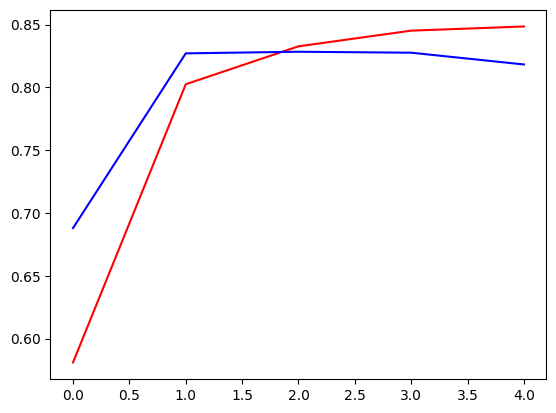

In [1]:
# Step 1: Import Libraries and Load the Model
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import load_model

In [2]:
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

In [3]:
# Load the pre-trained model with ReLU activation
model = load_model('rnn_model.h5')
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 300, 100)       │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_24 (SimpleRNN)       │ (None, 300, 64)        │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 300, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_25 (SimpleRNN)       │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513,699 (1.96 MB)

 Trainable params: 513,697 (1.96 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [4]:
model.get_weights()

[array([[-0.03029734,  0.00643796,  0.02044902, ..., -0.10991479,
          0.00031067,  0.02272047],
        [-0.04815122, -0.07743453, -0.041547  , ..., -0.03489012,
         -0.01970129,  0.03533111],
        [-0.01381298,  0.03588255,  0.05782934, ..., -0.0581445 ,
          0.01689384,  0.0147898 ],
        ...,
        [ 0.0589067 ,  0.01105709, -0.02816822, ...,  0.06505026,
          0.00180676, -0.05640227],
        [ 0.12027817,  0.00857883,  0.00769254, ...,  0.04041914,
          0.06164059, -0.00318259],
        [ 0.08737551, -0.08368912,  0.04359267, ...,  0.06136298,
          0.04591378,  0.03567479]], shape=(5000, 100), dtype=float32),
 array([[-0.27242306, -0.05324898, -0.0081916 , ...,  0.13679314,
         -0.11282428,  0.0202944 ],
        [ 0.01206311, -0.10920667,  0.1336996 , ..., -0.05049044,
          0.15677984,  0.01218139],
        [-0.13365969, -0.08900866,  0.0870854 , ...,  0.25375226,
          0.04635591,  0.22926934],
        ...,
        [-0.23704825

In [ ]:
def preprocess_text(text):
    words = text.lower().split()
    encoded_review = [word_index.get(word, 2) + 3 for word in words]
    padded_review = sequence.pad_sequences([encoded_review], maxlen=500)
    return padded_review

In [29]:
### Prediction  function

def predict_sentiment(review):
    preprocessed_input=preprocess_text(review)

    prediction=model.predict(preprocessed_input)

    sentiment = 'Positive' if prediction[0][0] > 0.7 else 'Negative'
    
    return sentiment, prediction[0][0]



In [30]:
#
example_review = "This movie was fantastic! The acting was great and the plot was thrilling."

sentiment,score=predict_sentiment(example_review)

print(f'Review: {example_review}')
print(f'Sentiment: {sentiment}')
print(f'Prediction Score: {score}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Review: This movie was fantastic! The acting was great and the plot was thrilling.
Sentiment: Positive
Prediction Score: 0.9070290327072144


In [31]:
#
example_review2 = "This movie was bad and acting is not so good "

sentiment2,score2=predict_sentiment(example_review2)

print(f'Review: {example_review2}')
print(f'Sentiment: {sentiment2}')
print(f'Prediction Score: {score2}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Review: This movie was bad and acting is not so good 
Sentiment: Negative
Prediction Score: 0.49439144134521484


In [32]:
#
example_review3 = "this movie is super"

sentiment3,score3=predict_sentiment(example_review3)

print(f'Review: {example_review3}')
print(f'Sentiment: {sentiment3}')
print(f'Prediction Score: {score3}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Review: this movie is super
Sentiment: Positive
Prediction Score: 0.9289638996124268


In [33]:
#
example_review3 = "this movie is bad "

sentiment3,score3=predict_sentiment(example_review3)

print(f'Review: {example_review3}')
print(f'Sentiment: {sentiment3}')
print(f'Prediction Score: {score3}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Review: this movie is bad 
Sentiment: Negative
Prediction Score: 0.6569758653640747
